In [ ]:
from pathlib import Path
import pandas as pd

def find_root(start: Path = Path.cwd()) -> Path:
    # Look for a directory that has 'data' and 'reports', walk up from current working dir
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "reports").exists():
            return p
    return start

ROOT = find_root()
DATA_DIR = ROOT / "data" / "raw"
FIG_DIR  = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Retreiving dataset
df = pd.read_excel(DATA_DIR / "TFR.xlsx", skiprows=2, nrows=2, index_col=0)
df

,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Number of Birth,966.00,923.00,874.00,796.0,825.00,751.00,863.0,863.00,867.00,848.00,...,435.400,438.400,406.200,357.800,326.800,302.700,272.300,260.600,249.10,230.00
Total Fertility Rate,4.07,3.77,3.43,3.0,2.99,2.64,2.9,2.82,2.57,2.39,...,1.205,1.239,1.172,1.052,0.977,0.918,0.837,0.808,0.78,0.72


In [5]:
# Transposing index and columns
df = df.T
df.head()

,Number of Birth,Total Fertility Rate
1973,966.0,4.07
1974,923.0,3.77
1975,874.0,3.43
1976,796.0,3.00
1977,825.0,2.99


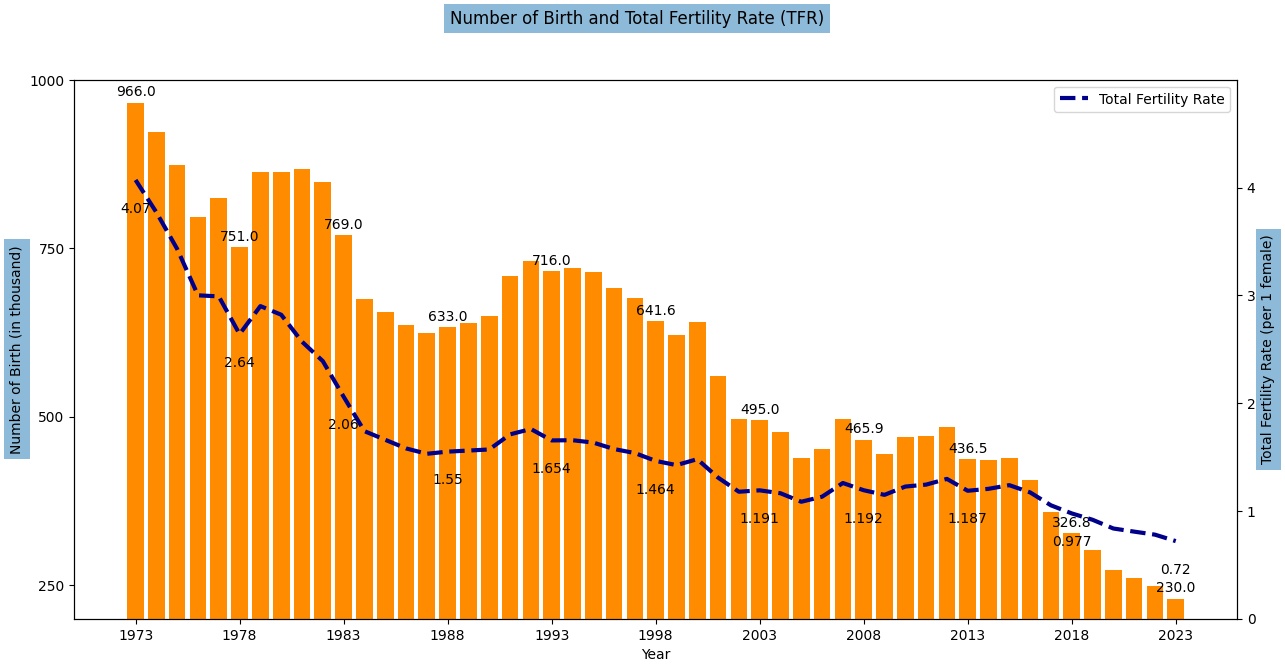

In [6]:
fig,ax1 = plt.subplots(figsize=(15,7))
fig.suptitle('Number of Birth and Total Fertility Rate (TFR)', bbox=dict(alpha=0.5, edgecolor='none'))
plt.xlabel('Year')
ax1.set_ylabel('Number of Birth (in thousand)', bbox=dict(alpha=0.5, edgecolor='none'))
ax1.set_ylim(200, 1000)
ax1.set_yticks([250, 500, 750, 1000])
ax1.bar(df.index, df['Number of Birth'], color='darkorange')
for idx, val in enumerate(df['Number of Birth']):
    if idx % 5 == 0:
        ax1.text(idx, val + 10, val, ha='center')  

ax2 = ax1.twinx()
ax2.set_ylabel('Total Fertility Rate (per 1 female)', bbox=dict(alpha=0.5, edgecolor='none'))
ax2.set_ylim(0, 5)
ax2.set_yticks([0, 1, 2, 3, 4])

ticks = []
for tick in range(55):
    if tick % 10 == 0 or tick % 5 ==0:
        ticks.append(tick)
plt.xticks(ticks)

ax2.plot(df.index, df['Total Fertility Rate'], color='darkblue', ls='--', lw=3, label = 'Total Fertility Rate')
plt.legend(loc='best')
for idx, val in enumerate(df['Total Fertility Rate']):
    if idx % 5 == 0:
        ax2.text(idx, val - 0.3, val, ha='center')